In [1]:
!pip install mesa
import mesa

# Data visualization tools.
import seaborn as sns

# Has multi-dimensional arrays and matrices. Has a large collection of
# mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

!pip install solara
from mesa.visualization import SolaraViz, make_plot_component, make_space_component


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.1/275.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.0/269.0 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 57.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


In [2]:
import random
class Persona(mesa.Agent):
    def __init__(self, model, tipo: int, se_ha_movido: bool) -> None:
        super().__init__(model)
        self.tipo = tipo
        self.se_ha_movido = se_ha_movido

    def incomodidad(self,pos,tipo):
        contador = 0
        vecindad = self.model.grid.get_neighbors(pos, moore=True, include_center=False)
        if tipo == 1:
            for vecino in vecindad:
              if vecino.tipo == -1: contador += 1
        elif tipo == -1:
            for vecino in vecindad:
              if vecino.tipo == 1: contador += 1
        elif tipo == 0:
            for vecino in vecindad: contador += abs(vecino.tipo)
        return contador

    def move(self):
        self.se_ha_movido = False
        possible_steps = []
        radio = 0
        max_iteraciones = self.model.grid.width // 2 + 1
        incomodidad_base = self.incomodidad(self.pos,self.tipo)

        if incomodidad_base > self.model.tolerance:
            while not possible_steps and radio < max_iteraciones:
                radio += 1
                vecindario = self.model.grid.get_neighborhood(
                    self.pos, moore=True, include_center=False, radius=radio
                )
                empty_steps = [step for step in vecindario if self.model.grid.is_cell_empty(step)]
                possible_steps = [step for step in empty_steps if self.incomodidad(step, self.tipo) < incomodidad_base]

        # Si encontró opciones válidas, moverse
        if possible_steps:
          new_position = random.choice(possible_steps)
          self.model.grid.move_agent(self, new_position)
          self.se_ha_movido = True

class Modelo_Desplazamiento(mesa.Model):
    def __init__(self, N1, N2, N3, width, height, tol, seed=None):
        super().__init__(seed=seed)
        self.num_agents = N1+N2+N3
        self.grid = mesa.space.SingleGrid(width, height, True)
        self.running = True
        self.tolerance = tol  # Add tolerance as a model parameter
        self.steps_to_equilibrium = 0
        self.in_equilibrium = False

        for i in range(N1): Persona(model=self, tipo=1, se_ha_movido=False)
        for i in range(N2): Persona(model=self, tipo=0, se_ha_movido=False)
        for i in range(N3): Persona(model=self, tipo=-1, se_ha_movido=False)

                # Ensure agents are placed in different locations
        placed_agents = set()
        for i in range(self.num_agents):
            agent = self.agents[i]
            x, y = random.randrange(self.grid.width), random.randrange(self.grid.height)
            while (x, y) in placed_agents:
                x, y = random.randrange(self.grid.width), random.randrange(self.grid.height)
            placed_agents.add((x, y))
            self.grid.place_agent(agent, (x, y))

    def check_equilibrium(self) -> bool:
        """Verifica si el modelo ha alcanzado el equilibrio"""
        for agent in self.agents:
            if agent.se_ha_movido:
                return False
        return True

    def step(self):
        if not self.in_equilibrium:
            self.agents.shuffle_do("move")
            #self.calculate_contact_measure()
            #self.calculate_unsatisfied()

            if self.check_equilibrium():
                self.in_equilibrium = True
                self.running = False
            else:
                self.steps_to_equilibrium += 1

def agent_portrayal(agent):
    portrayal = {
        "size": 50,
        "shape": "circle",
        "layer": 0,
    }

    if agent.tipo == 1:
        portrayal["color"] = "tab:blue"
    elif agent.tipo == 0:
        portrayal["color"] = "tab:yellow"
    elif agent.tipo == -1:
        portrayal["color"] = "tab:red"
    else:
        portrayal["color"] = "gray"

    return portrayal


model_params = {
    "N1": 30,
    "N2": 30,
    "N3": 30,
    "width": 10,
    "height": 10,
    "tol": 2,
}

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

def plot_grid_state(model, ax, title, title_fontsize=12, legend_fontsize=10):
    grid_width = model.grid.width
    grid_height = model.grid.height
    grid_data = np.zeros((grid_height, grid_width, 3)) # For RGB colors

    color_map = {
        1: [0, 0, 1],   # Blue for tipo 1
        0: [1, 1, 0],   # Yellow for tipo 0
        -1: [1, 0, 0], # Red for tipo -1
    }

    # Iterate through each cell to get agent types
    for cell_content, (x, y) in model.grid.coord_iter():
        if cell_content: # If there's an agent
            agent = cell_content
            color = color_map.get(agent.tipo, [0.5, 0.5, 0.5]) # Gray for unknown types
            grid_data[y, x] = color
        else:
            grid_data[y, x] = [0.8, 0.8, 0.8] # Light gray for empty cells

    ax.imshow(grid_data, origin='lower') # origin='lower' to match grid coordinates
    ax.set_xticks([]) # Remove x-axis tick marks
    ax.set_yticks([]) # Remove y-axis tick marks
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    # ax.grid(True, which='both', color='lightgray', linestyle='-', linewidth=0.5) # Removed grid lines
    # ax.set_title(title, fontsize=title_fontsize) # Keep this commented out or remove if no title is ever desired

    # Removed the legend generation as requested
    # legend_handles = []
    # for tipo, color_rgb in color_map.items():
    #     legend_handles.append(Patch(color=np.array(color_rgb), label=f'Tipo {tipo}'))
    # ax.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=legend_fontsize)

Iniciando simulación de barrido de parámetros para valores variables de N0, manteniendo 1500 agentes en total.
Tamaño de la cuadrícula: 40x40, Tolerancia: 0, Pasos por simulación: 30

--- Simulación para N1=750, N0=0, N-1=750 ---


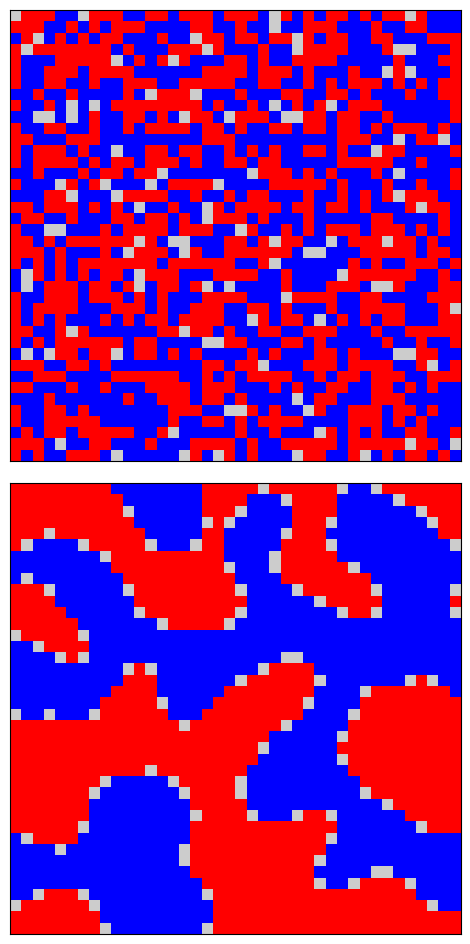


--- Simulación para N1=600, N0=300, N-1=600 ---


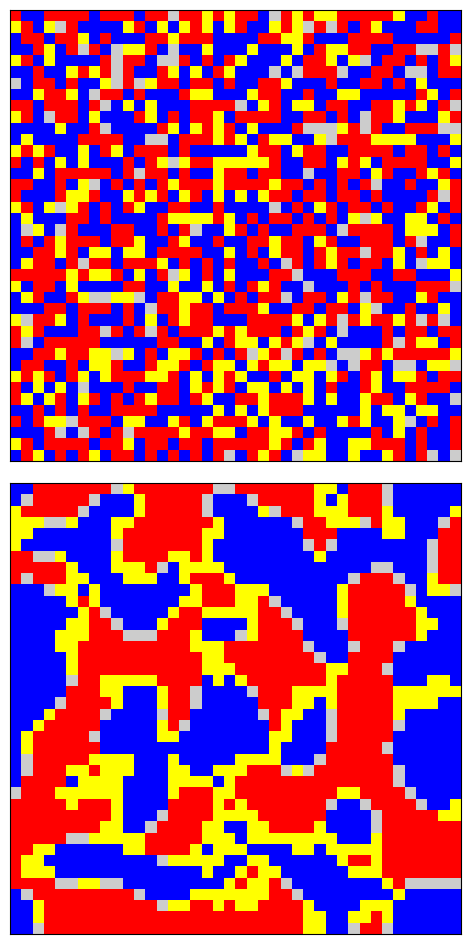


--- Simulación para N1=500, N0=500, N-1=500 ---


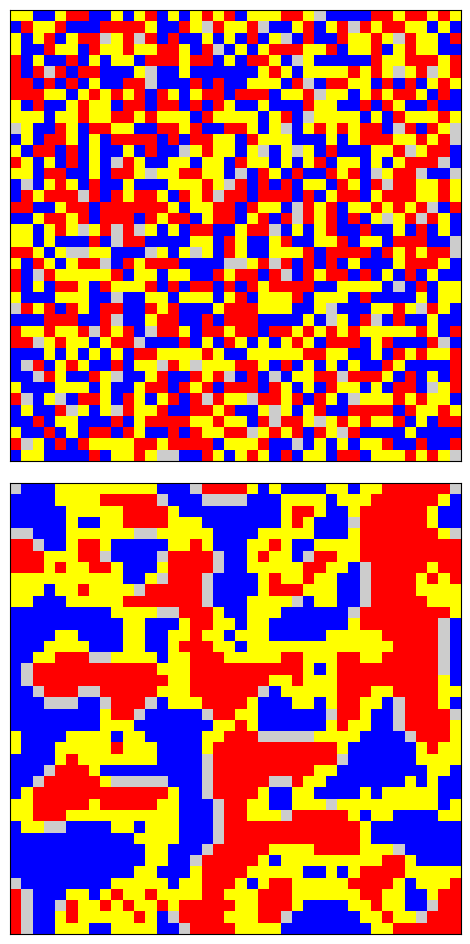


--- Simulación para N1=400, N0=700, N-1=400 ---


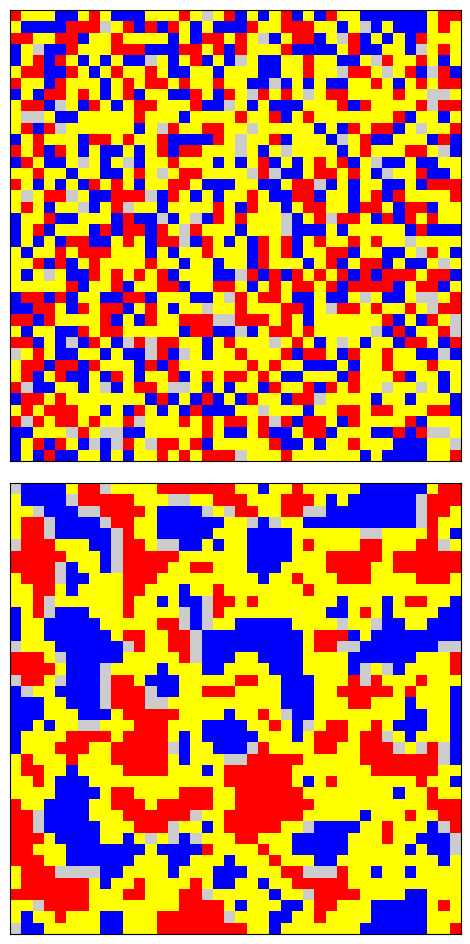


--- Resumen de imágenes generadas (4) ---
schelling_sim_N0_0.png
schelling_sim_N0_300.png
schelling_sim_N0_500.png
schelling_sim_N0_700.png

Todas las simulaciones y visualizaciones han sido completadas.


In [4]:
import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'

total_agents = 1500
# Usando parámetros de la última celda de visualización ejecutada (f680b2b7) que se ejecutó con éxito
fixed_width = 40
fixed_height = 40
fixed_tol = 0 # Tolerancia de model_params
num_simulation_steps = 30 # Número de pasos para cada simulación

print(f"Iniciando simulación de barrido de parámetros para valores variables de N0, manteniendo {total_agents} agentes en total.")
print(f"Tamaño de la cuadrícula: {fixed_width}x{fixed_height}, Tolerancia: {fixed_tol}, Pasos por simulación: {num_simulation_steps}")

generated_image_files = []

# Define font sizes for better control
main_title_fontsize = 25
subplot_title_fontsize = 20
legend_item_fontsize = 10

# N2 varía de 0 a 1400, con un incremento de 100. Esto asegura que N1 y N3 sean enteros y positivos.
for N2_val in [0, 300, 500, 700]:
    remaining_agents = total_agents - N2_val
    if remaining_agents % 2 != 0:
        print(f"Saltando N0={N2_val} ya que (total_agents - N2_val) es impar, N1 y N3 no serían enteros.")
        continue

    N1_val = remaining_agents // 2
    N3_val = remaining_agents // 2

    print(f"\n--- Simulación para N1={N1_val}, N0={N2_val}, N-1={N3_val} ---")

    # Instanciar el modelo para el conjunto de parámetros actual
    current_model = Modelo_Desplazamiento(
        N1=N1_val,
        N2=N2_val,
        N3=N3_val,
        width=fixed_width,
        height=fixed_height,
        tol=fixed_tol,
    )

    # Crear una figura con dos subplots para esta ejecución (estado inicial y final)
    # Changed to 2 rows, 1 column for vertical layout
    fig_run, axes_run = plt.subplots(2, 1, figsize=(8, 12)) # Adjusted figsize for vertical layout
    fig_run.subplots_adjust(hspace=0.05) # Adjust vertical spacing between subplots

    # Plotear el estado inicial (top subplot)
    plot_grid_state(current_model, axes_run[0], '')

    # Ejecutar el modelo por el número especificado de pasos
    for _ in range(num_simulation_steps):
        current_model.step()

    # Plotear el estado final (bottom subplot)
    plot_grid_state(current_model, axes_run[1], '')

    # Guardar la figura
    run_file_name = f'schelling_sim_N0_{N2_val}.png'
    fig_run.savefig(run_file_name, bbox_inches='tight')
    generated_image_files.append(run_file_name)
    plt.show() # Mostrar cada gráfico a medida que se genera
    plt.close(fig_run) # Cerrar la figura para liberar memoria después de mostrarla y guardarla

print(f"\n--- Resumen de imágenes generadas ({len(generated_image_files)}) ---")
for f_name in generated_image_files:
    print(f_name)

print("\nTodas las simulaciones y visualizaciones han sido completadas.")

Preparando para combinar 4 imágenes en una cuadrícula...


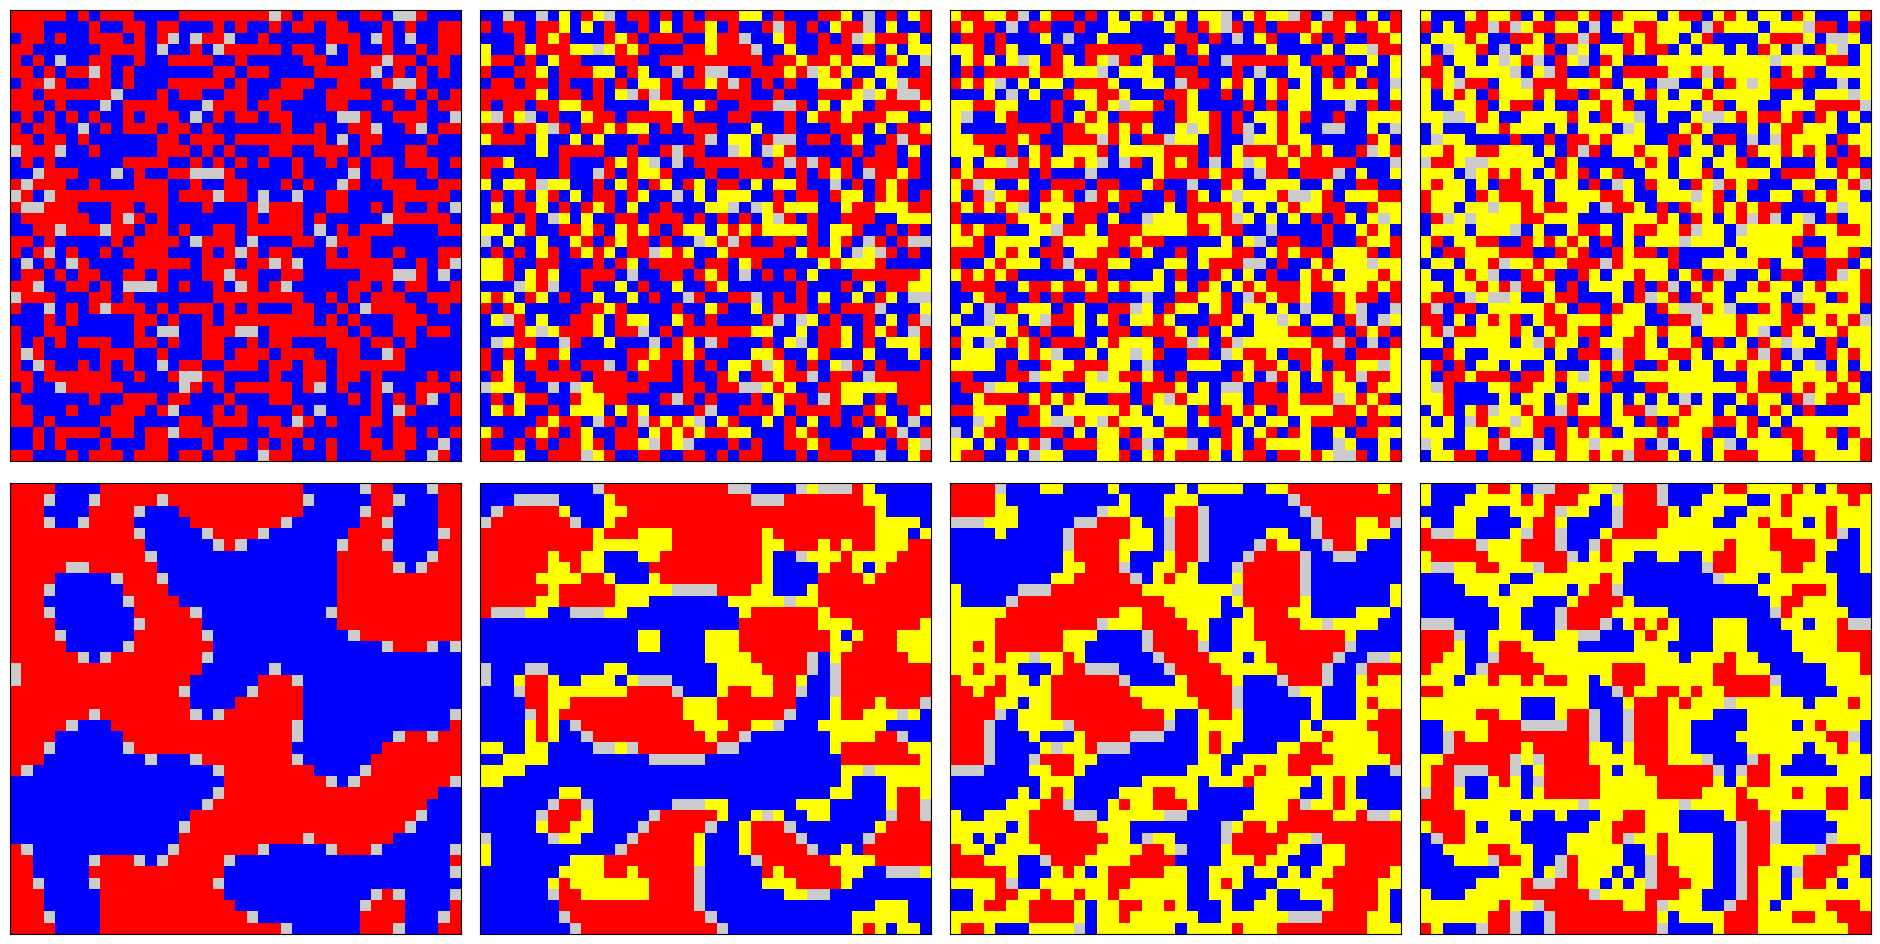

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from PIL import Image, ImageDraw, ImageFont
import math
from google.colab import files

plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'

print(f"Preparando para combinar {len(generated_image_files)} imágenes en una cuadrícula...")

# Define the font size for the tolerance text (no longer used, but kept for reference if needed later)
tolerance_text_fontsize = 24

if not generated_image_files:
    print("No se encontraron imágenes para combinar. Por favor, asegúrese de que las simulaciones se ejecutaron correctamente.")
else:
    images = [Image.open(f) for f in generated_image_files]
    if not images:
        print("No se pudieron cargar las imágenes.")
    else:
        img_width, img_height = images[0].size

        num_images = len(images)
        cols = num_images # Arrange all images in a single row
        rows = 1

        grid_width = cols * img_width
        grid_height = rows * img_height

        # Create the grid of images with white background
        final_image = Image.new('RGB', (grid_width, grid_height), color='white')

        for index, img in enumerate(images):
            col = index # Simply use index for column as there's only one row
            row = 0     # Always the first row
            x_offset = col * img_width
            y_offset = row * img_height
            final_image.paste(img, (x_offset, y_offset))

        # No longer adding text or extra space below the grid

        # Save as PNG
        output_filename_png = 'schelling_all_simulations_combined.png'
        final_image.save(output_filename_png)

        display(final_image)
        files.download(output_filename_png)

        # Save as PDF
        output_filename_pdf = 'schelling_all_simulations_combined.pdf'
        # Convert to RGB if not already (PDF doesn't support RGBA directly for all cases)
        if final_image.mode == 'RGBA':
            final_image = final_image.convert('RGB')
        final_image.save(output_filename_pdf)

        files.download(output_filename_pdf)